# Interfaces

A battery, a transistor and a coated turbine blade are all made of interfaces,
and interfaces are where devices fail. Two materials that are each perfectly
stable on their own can destroy each other the moment they touch. Two that are
chemically compatible may still be unable to grow on one another because their
lattices do not fit.

Neither failure is visible from either material alone, which is why an
interface needs its own object rather than a column.

This page asks the three questions separately, because they are separate:

| | |
|---|---|
| will the lattices match? | `mv.iface.match` — Zur and McGill's algorithm |
| what happens at the contact? | `mv.iface.reactivity` — the interfacial hull |
| can I build the cell? | `mv.iface.build` — the coherent interface |

In [1]:
import matverse as mv
import numpy as np
import pandas as pd

mv.pl.set_style()

🔬 Starting plot initialization...
🧪 Calculators available: 6
    • emt — EMT (LGPL-2.1)
    • lj — Lennard-Jones (LGPL-2.1)
    • mace-mpa — mace-mpa (unstated)
    • mace-omat — mace-omat (unstated)
    • sevennet — sevennet (unstated)
    • chgnet — chgnet (unstated)


🖥️ NVIDIA CUDA GPUs: 1
    • [CUDA 0] NVIDIA H100 80GB HBM3 — 79.1 GB, compute 9.0

                   __
   ____ ___  ____ _/ /__   _____  _____________
  / __ `__ \/ __ `/ __/ | / / _ \/ ___/ ___/ _ \
 / / / / / / /_/ / /_ | |/ /  __/ /  (__  )  __/
/_/ /_/ /_/\__,_/\__/ |___/\___/_/  /____/\___/

🔖 Version: 0.1.71   🧮 Functions: 211   📚 Tutorials: https://matverse.readthedocs.io/
✅ set_style complete.



## Loading a dataset

Three fcc metals at their published lattice parameters. Aluminium and nickel
are the interesting pair: they are the basis of the superalloys that turbine
blades are made of, and they react.

In [2]:
md = mv.datasets.metals(["Cu", "Al", "Ni"])
mv.pp.describe(md)
mv.calc.energy(md, level="emt")

md.obs[["name", "lattice_parameter", "density"]].round(3)

,name,lattice_parameter,density
0,Cu,3.615,8.935
1,Al,4.050,2.699
2,Ni,3.524,8.908


## Will the lattices match?

Epitaxy needs a supercell of the film that fits a supercell of the substrate.
Zur and McGill (1984) search for one, and the answer is a **list** of matches
per orientation pair rather than a yes or a no — which is why the result gets
its own axis.

In [3]:
pairs = mv.iface.match(md, max_area=120.0)
pairs

AnnData object with n_obs × n_vars = 6 × 0
    obs: 'film', 'substrate', 'film_index', 'substrate_index', 'film_miller', 'substrate_miller', 'match_area', 'von_mises_strain', 'n_matches', 'epitaxial'
    uns: 'matverse_axis', 'provenance', 'match'
    layers: None (.X)

In [4]:
pairs.obs[["film", "substrate", "film_miller", "substrate_miller",
           "match_area", "von_mises_strain", "n_matches", "epitaxial"]].round(4)

,film,substrate,film_miller,substrate_miller,match_area,von_mises_strain,n_matches,epitaxial
Cu|Al,Cu,Al,1_0_0,1_0_0,65.3375,0.0013,3,True
Cu|Ni,Cu,Ni,1_0_0,1_1_0,91.4725,0.0144,7,True
Al|Cu,Al,Cu,1_0_0,1_0_0,65.5938,0.0013,1,True
Al|Ni,Al,Ni,1_1_1,1_1_1,85.2088,0.0032,3,True
Ni|Cu,Ni,Cu,1_1_0,1_0_0,87.8126,0.0152,7,True
Ni|Al,Ni,Al,1_1_1,1_1_1,86.0384,0.0032,3,True


Six rows for three materials: the pairing is **ordered**, because copper grown
on aluminium is a different problem from aluminium grown on copper. The
substrate is the fixed lattice and the film is what has to stretch.

Every pairing here matches at well under 1% strain, which is what you would
expect — all three are fcc with lattice parameters within 15% of each other,
and the algorithm has supercells to play with.

`von_mises_strain` is the column to screen on. Coherent epitaxy needs it below
roughly 5%; above that the film relaxes by making dislocations instead, and the
coherent interface you were designing does not exist.

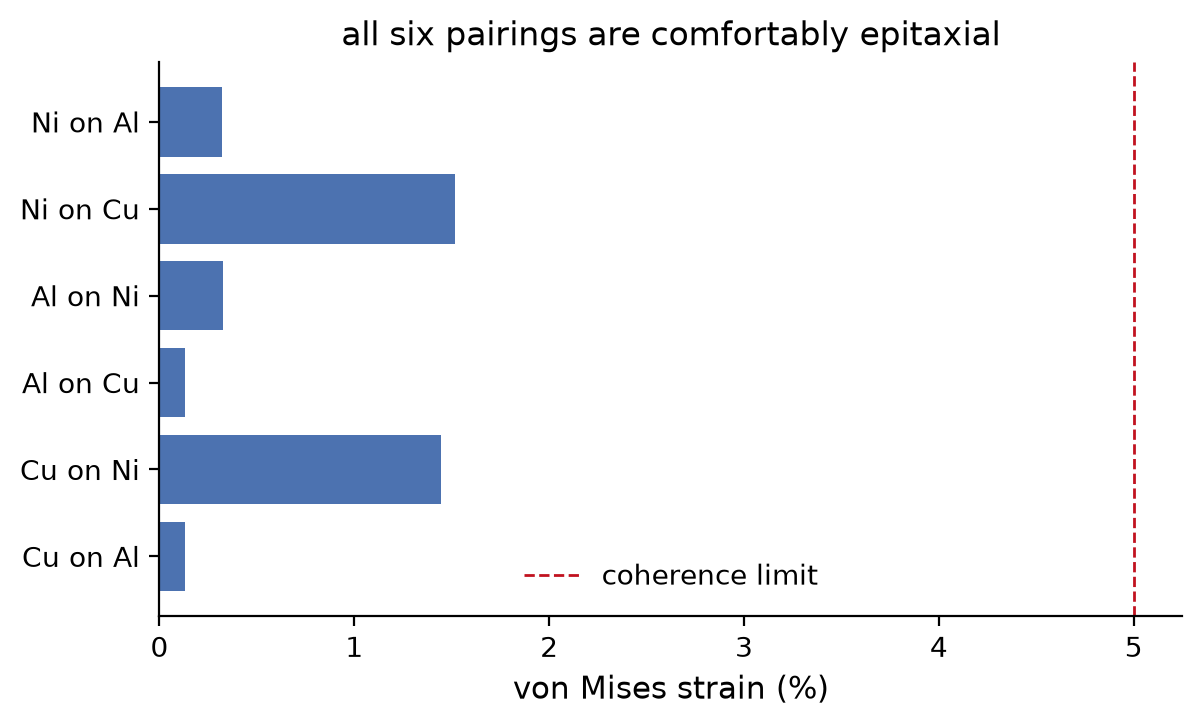

In [5]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(6.6, 3.6))
labels = [f"{f} on {s}" for f, s in zip(pairs.obs["film"],
                                        pairs.obs["substrate"])]
strain = 100 * pairs.obs["von_mises_strain"].to_numpy(dtype=float)
ax.barh(labels, strain, color="#4c72b0")
ax.axvline(5.0, linestyle="--", color="#c1121f", linewidth=1.0,
           label="coherence limit")
ax.set_xlabel("von Mises strain (%)")
ax.set_title("all six pairings are comfortably epitaxial")
ax.legend()

Tighten the threshold and the screen starts discriminating — which is the
point of it being a parameter rather than a constant.

In [6]:
strict = mv.iface.match(md, max_area=120.0, max_strain=0.005)
strict.obs[["film", "substrate", "von_mises_strain", "epitaxial"]].round(4)

,film,substrate,von_mises_strain,epitaxial
Cu|Al,Cu,Al,0.0013,True
Cu|Ni,Cu,Ni,0.0144,False
Al|Cu,Al,Cu,0.0013,True
Al|Ni,Al,Ni,0.0032,True
Ni|Cu,Ni,Cu,0.0152,False
Ni|Al,Ni,Al,0.0032,True


## What happens at the contact?

Lattice matching says the film can grow. It says nothing about whether the two
materials will still be there afterwards.

`mv.iface.reactivity` reads the answer off the phase diagram of the combined
chemistry, minimising over every mixing ratio — so the number is the worst case
rather than the 1:1 case.

In [7]:
mv.iface.reactivity(pairs, md, level="emt")

pairs.obs[["film", "substrate", "reaction_energy_emt", "reacts_emt"]].round(4)

,film,substrate,reaction_energy_emt,reacts_emt
Cu|Al,Cu,Al,0.0,False
Cu|Ni,Cu,Ni,0.0,False
Al|Cu,Al,Cu,0.0,False
Al|Ni,Al,Ni,0.0,False
Ni|Cu,Ni,Cu,0.0,False
Ni|Al,Ni,Al,0.0,False


All zero, and that is the correct answer for this dataset rather than a
failure. The phase diagram contains three elements and no compounds, so there
is nothing for them to react *into*. EMT compounds the point: as the [screening
tutorial](screening.ipynb) showed, its energy zero is the pure element, so no
intermetallic can ever come out below the hull.

Give the diagram a compound that is genuinely stable and the same call finds
the reaction. Al₃Ni is a real phase with a formation energy near −0.45 eV/atom:

In [8]:
from pymatgen.core import Lattice, Structure


def l12(host, guest, a):
    return Structure(Lattice.cubic(a), [guest, host, host, host],
                     [[0, 0, 0], [0, .5, .5], [.5, 0, .5], [.5, .5, 0]])


alni = mv.data.from_structures(
    mv.structures(mv.datasets.metals(["Al", "Ni"])) + [l12("Al", "Ni", 3.78)])
mv.pp.describe(alni)

alni.obs["energy_per_atom_lit"] = [0.0, 0.0, -0.45]
mv.set_level(alni, "lit", kind="dft", method="literature formation energies",
             reference="experiment")

alni.obs[["formula", "energy_per_atom_lit"]]

,formula,energy_per_atom_lit
0,Al,0.00
1,Ni,0.00
2,Al3Ni,-0.45


In [9]:
contacts = mv.iface.match(alni, max_area=120.0)
mv.iface.reactivity(contacts, alni, level="lit")

contacts.obs[["film", "substrate", "reaction_energy_lit", "reacts_lit",
              "reaction_lit"]].round(4)

,film,substrate,reaction_energy_lit,reacts_lit,reaction_lit
0|1,0,1,-0.45,True,Ni + 3 Al -> Al3Ni
0|2,0,2,0.00,False,Al3Ni -> Al3Ni
1|0,1,0,-0.45,True,Ni + 3 Al -> Al3Ni
1|2,1,2,0.00,False,Al3Ni -> Al3Ni
2|0,2,0,0.00,False,4 Al -> 4 Al
2|1,2,1,0.00,False,4 Ni -> 4 Ni


**Ni + 3 Al → Al₃Ni at −0.45 eV/atom.** Put aluminium against nickel and it
does not stay a bilayer; it forms an intermetallic, which is exactly what
happens in a real Ni–Al system and exactly why diffusion barriers exist in
turbine coatings.

```{warning}
This is the question that decides whether a solid electrolyte works. Lithium
metal and most sulfide electrolytes are each stable, and they destroy each
other on contact — a fact invisible to a hull computed on either one alone.

A reaction energy of zero means inert **with respect to the phases in this
dataset**, which is a much weaker claim than inert. `uns['reactivity']` records
that the system is closed; pass a complete phase diagram to make it a real
claim.
```

## Building the cell

Matching says it fits and reactivity says it survives. Now build the thing you
would actually run DFT on.

In [10]:
interfaces = mv.iface.build(md, film="Cu", substrate="Al",
                            film_miller=(1, 1, 1),
                            substrate_miller=(1, 1, 1))
mv.pp.describe(interfaces)

interfaces.obs[["film", "substrate", "film_miller", "termination",
                "nsites", "volume"]].round(2)

,film,substrate,film_miller,termination,nsites,volume
0,Cu,Al,1_1_1,"('Cu_R-3m_1', 'Al_R-3m_1')",7,468.65


In [11]:
interfaces.uns["interface"]

{'film': 'Cu',
 'substrate': 'Al',
 'film_miller': [1, 1, 1],
 'substrate_miller': [1, 1, 1],
 'gap': 2.0,
 'vacuum': 20.0,
 'n_terminations': 1}

One cell per **termination**. Cutting the same orientation at a different plane
gives a different interface with a different energy, and which one forms
depends on growth conditions — so they are enumerated rather than guessed, the
same way `mv.surf.slabs` enumerates surface terminations.

The result is an **ordinary materials object**. An interface is a structure,
and matverse has no reason to treat it as a special kind of thing — so it
relaxes, screens and plots like anything else:

In [12]:
sorted({str(s) for s in mv.structures(interfaces)[0].species})

['Al', 'Cu']

In [13]:
mv.calc.relax(interfaces, level="emt", fmax=0.1, steps=40)

interfaces.obs[["termination", "energy_per_atom_emt",
                "relax_converged_emt"]].round(4)

,termination,energy_per_atom_emt,relax_converged_emt
0,"('Cu_R-3m_1', 'Al_R-3m_1')",0.4044,True


```{note}
The interface cells pymatgen returns carry a numpy array as a site property —
the interface-normal vector. Storing them used to fail with a bare
`TypeError: Object of type ndarray is not JSON serializable`, because matverse
serialises structures to JSON so the object survives `write_h5ad`. The encoder
now converts arrays, and refuses anything it genuinely cannot store with a
message naming the property rather than the type.
```

## The chain, end to end

Match, react, build — and the pairs object screens like any other.

In [14]:
mv.screen.filter(pairs, von_mises_strain__lt=0.01,
                 reaction_energy_emt__ge=-0.01, name="usable")

pairs.obs[["film", "substrate", "von_mises_strain", "reaction_energy_emt",
           "usable"]].round(4)

,film,substrate,von_mises_strain,reaction_energy_emt,usable
Cu|Al,Cu,Al,0.0013,0.0,True
Cu|Ni,Cu,Ni,0.0144,0.0,False
Al|Cu,Al,Cu,0.0013,0.0,True
Al|Ni,Al,Ni,0.0032,0.0,True
Ni|Cu,Ni,Cu,0.0152,0.0,False
Ni|Al,Ni,Al,0.0032,0.0,True


A pairing is usable when the lattices fit *and* the contact is inert. Neither
condition alone is enough, and both come from the same object.

## What it remembers

In [15]:
for step in mv.provenance(pairs):
    print(step)

iface.match(source='input', max_area=120.0, max_strain=0.05)
iface.reactivity(level='emt', source='input')
screen.filter(name='usable', von_mises_strain__lt=0.01, reaction_energy_emt__ge=-0.01)


```{seealso}
[Surfaces and adsorption](surfaces_and_adsorption.ipynb) covers the one-material
half of the same problem. [Screening, end to end](screening.ipynb) explains why
an EMT hull can never place an intermetallic below the line.
```